In [5]:
# Load df_artists and df_songs from CSV (no data is modified here — we only read files)

from pathlib import Path
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

# Your original data directory (keep this as-is if that's what you want)
DATA_DIR = Path('/Users/oceanito/Desktop/spring-2026-hitmakers-main 2')

# If you move the project / run from another machine, this fallback finds the project root.
if not (DATA_DIR / 'df_artists.csv').exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'df_artists.csv').exists():
            DATA_DIR = p
            break

print('Using DATA_DIR:', DATA_DIR.resolve())

df_artists = pd.read_csv(DATA_DIR / 'df_artists.csv')
print('df_artists:', df_artists.shape)

df_songs = pd.read_csv(DATA_DIR / 'df_songs.csv')
print('df_songs:', df_songs.shape)


Using DATA_DIR: /Users/oceanito/Desktop/spring-2026-hitmakers-main 2
df_artists: (13655, 44)
df_songs: (38383, 43)


In [6]:
df_artists.head()

,name,musicbrainz_artist_id,musicbrainz_mbid,spotify_id,performer_pre_normalized,first_top_20_hit_year,first_charting_song_year,last_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,first_song_year,years_active_on_charts,first_charting_song_position,first_charting_song_duration,top_20_hit_song_#_wks_on_chart_any_position,genre_tags_musicbrainz,first_year_on_chart_songs,genre_tags_through_first_top_10_hit,major_genre_categories_through_first_top_10_hit,#_of_major_genre_categories_through_first_top_10_hit,musicbrainz_major_genre_categories,musicbrainz_#_of_genres,spotify_genres,spotify_major_genre_categories,combined_major_genre_categories,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,!!! (chk chk chk),NaN,NaN,NaN,!!! (Chk Chk Chk),NaN,NaN,NaN,NaN,NaN,NaN,2007-2007,0,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"""groove"" holmes",NaN,NaN,NaN,"""Groove"" Holmes",NaN,1966.0,1966.0,NaN,NaN,1966.0,1966-1966,44,11,NaN,NaN,1966.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"""little"" jimmy dickens",NaN,NaN,NaN,"""Little"" Jimmy Dickens",1965.0,1965.0,1965.0,1.0,1.0,1965.0,1965-1965,15,10,NaN,NaN,1965.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,"""pookie"" hudson",232958.0,29dc9009-015f-47c4-bd17-ed2af6d2ae0c,NaN,"""Pookie"" Hudson",NaN,1963.0,1963.0,NaN,NaN,1963.0,1963-1963,96,1,NaN,NaN,1963.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"""weird al"" yankovic",NaN,NaN,NaN,"""Weird Al"" Yankovic",1984.0,1983.0,2014.0,2.0,4.0,1983.0,1983-2014,63,8,NaN,NaN,1983.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [7]:
# 1. Add google_trend_decay column to df_songs from df_songs_google_decay.csv
# 2. Fill centrality metrics with 0 (standard: no collaboration data = no centrality)

print("=" * 80)
print("ADDING ENGINEERED FEATURES & IMPUTATION")
print("=" * 80)

# Load the google_decay feature
df_songs_google_decay = pd.read_csv(DATA_DIR / 'df_songs_google_decay.csv')
print(f"\ndf_songs_google_decay loaded: {df_songs_google_decay.shape}")

# Merge on all common columns (excluding google_trend_decay which is new)
# Since both have the same rows in the same order, we can safely add the column
df_songs['google_trend_decay'] = df_songs_google_decay['google_trend_decay']
print(f"✓ google_trend_decay column added to df_songs")
print(f"  - Null values: {df_songs['google_trend_decay'].isnull().sum()} / {len(df_songs)}")

# Identify and fill centrality metrics with 0 (per standard: no collaboration data = no centrality)
centrality_cols = [col for col in df_songs.columns if 'centrality' in col.lower()]
if centrality_cols:
    print(f"\nFilling {len(centrality_cols)} centrality metric columns with 0:")
    for col in centrality_cols:
        null_count_before = df_songs[col].isnull().sum()
        df_songs[col] = df_songs[col].fillna(0)
        null_count_after = df_songs[col].isnull().sum()
        print(f"  {col}: {null_count_before} → {null_count_after}")
else:
    print("\nℹ️  No centrality columns found in df_songs")

print(f"\ndf_songs updated: {df_songs.shape}")
print(f"Total NaN cells in df_songs: {int(df_songs.isna().sum().sum())}")


ADDING ENGINEERED FEATURES & IMPUTATION

df_songs_google_decay loaded: (38383, 45)
✓ google_trend_decay column added to df_songs
  - Null values: 33807 / 38383

ℹ️  No centrality columns found in df_songs

df_songs updated: (38383, 44)
Total NaN cells in df_songs: 748101


In [70]:
# Save the updated df_songs with google_trend_decay to CSV

output_path = DATA_DIR / 'df_songs_with_google_decay.csv'
df_songs.to_csv(output_path, index=False)
print(f"✓ Saved updated df_songs to: {output_path.name}")
print(f"  Rows: {len(df_songs)}, Columns: {len(df_songs.columns)}")
print(f"\nNew columns in df_songs:")
print(f"  - google_trend_decay: {df_songs['google_trend_decay'].notna().sum()} non-null values")


✓ Saved updated df_songs to: df_songs_with_google_decay.csv
  Rows: 38383, Columns: 44

New columns in df_songs:
  - google_trend_decay: 4576 non-null values


In [71]:
# Optional: install xgboost (and shap, for optional interpretability) into this kernel
# If you already have these installed, you can skip this cell.

import importlib
import sys
import subprocess


def ensure_pkg(pkg: str):
    try:
        importlib.import_module(pkg)
        print(f"OK: {pkg}")
    except Exception:
        print(f"Installing: {pkg} ...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])


ensure_pkg('xgboost')
# ensure_pkg('shap')  # uncomment if you want SHAP plots


OK: xgboost


### Environment note

If you get an error like “Import `xgboost` could not be resolved” or `ImportError: xgboost is not available`, run **Cell 3** (the optional install cell) once — it installs into the current notebook kernel.

In [72]:
# Create df_artists_final from df_artists:
# - drops non-feature/identifier columns
# - filters to artists whose first top-20 hit was between 2000 and 2019
# - keeps combined_major_genre_categories, renamed to combined_major_genre_categories_artist

cols_to_drop = [
    'musicbrainz_artist_id', 'musicbrainz_mbid', 'spotify_id',
    'performer_pre_normalized', 'last_charting_song_year', 'first_song_year',
    'years_active_on_charts', 'first_charting_song_position',
    'first_charting_song_duration', 'genre_tags_musicbrainz',
    'first_year_on_chart_songs', 'genre_tags_through_first_top_10_hit',
    'major_genre_categories_through_first_top_10_hit',
    '#_of_major_genre_categories_through_first_top_10_hit',
    'musicbrainz_major_genre_categories', 'musicbrainz_#_of_genres',
    'spotify_genres', 'spotify_major_genre_categories',
]

df_artists_final = (
    df_artists[df_artists['first_top_20_hit_year'].between(2000, 2019)]
    .drop(columns=[c for c in cols_to_drop if c in df_artists.columns])
    .rename(columns={'combined_major_genre_categories': 'combined_major_genre_categories_artist'})
    .reset_index(drop=True)
)

print(df_artists_final.shape)
df_artists_final.head()


(778, 26)


,name,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,combined_major_genre_categories_artist,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,2 chainz,2012.0,2012.0,1.0,9.0,27.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0
1,21 savage,2017.0,2016.0,2.0,15.0,41.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0
2,3 doors down,2000.0,2000.0,1.0,2.0,53.0,"Metal, Pop, Rock","Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
3,3oh!3,2008.0,2008.0,1.0,1.0,37.0,"Electronic/Dance, Hip Hop/Rap, Pop, Punk/Hardc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,5 seconds of summer,2014.0,2014.0,1.0,6.0,20.0,"Pop, Punk/Hardcore",Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,0.000048,1.000000,0.000000,1.555431e-18,NaN,1.0


In [73]:
df_artists_final.columns
print(f"\nColumns in df_artists_final BEFORE google_decay merge: {list(df_artists_final.columns)}")
print(f"Shape: {df_artists_final.shape}")


Columns in df_artists_final BEFORE google_decay merge: ['name', 'first_top_20_hit_year', 'first_charting_song_year', 'years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'combined_major_genre_categories_artist', 'first_top_20_song_major_genres', 'first_top_20_song_duration_ms', 'first_top_20_song_acousticness', 'first_top_20_song_danceability', 'first_top_20_song_energy', 'first_top_20_song_instrumentalness', 'first_top_20_song_liveness', 'first_top_20_song_loudness', 'first_top_20_song_speechiness', 'first_top_20_song_tempo', 'first_top_20_song_valence', 'first_top_20_song_mode', 'first_top_20_song_explicit', 'degree_centrality_top20_rolling5', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'power_of_connected_artists_top20_rolling5', 'top_20_hitmaker']
Shape: (778, 26)


In [74]:
# Add google_trend_decay from song-level to artist-level
# Aggregate: mean google_trend_decay for each artist (single feature)
# Join key: name (normalized performer - matching df_artists_final key)

print("\n" + "=" * 80)
print("ADDING GOOGLE_TREND_DECAY FEATURE (Song-level → Artist-level)")
print("=" * 80)

# Aggregate google_trend_decay by normalized performer (name column in df_songs)
# Use MEAN as the primary metric (represents average decay across all songs)
google_decay_agg = df_songs[['name', 'google_trend_decay']].dropna(subset=['google_trend_decay']).groupby('name').agg(
    google_trend_decay=('google_trend_decay', 'mean')
).reset_index()

print(f"Aggregated google_trend_decay (mean) by {len(google_decay_agg)} unique performers")

# Merge into df_artists_final on 'name' column
df_artists_final = df_artists_final.merge(
    google_decay_agg, 
    on='name', 
    how='left'
)
print(f"✓ Merged google_trend_decay feature into df_artists_final")
print(f"  Shape: {df_artists_final.shape}")
print(f"  Artists with google_decay data: {df_artists_final['google_trend_decay'].notna().sum()} / {len(df_artists_final)}")
print(f"  New column added: google_trend_decay")



ADDING GOOGLE_TREND_DECAY FEATURE (Song-level → Artist-level)
Aggregated google_trend_decay (mean) by 675 unique performers
✓ Merged google_trend_decay feature into df_artists_final
  Shape: (778, 27)
  Artists with google_decay data: 364 / 778
  New column added: google_trend_decay


In [75]:
# One-hot encode combined_major_genre_categories_artist into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'artist_genre_', replacing the original column.

artist_genre_dummies = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='artist_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
artist_genre_dummies = artist_genre_dummies.loc[:, artist_genre_dummies.columns != 'artist_genre_']

# Insert genre columns where combined_major_genre_categories_artist was, then drop original
insert_at = df_artists_final.columns.get_loc('combined_major_genre_categories_artist')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    artist_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

# Add binary flag for artists with no genre data — inserted after last genre column
all_genre_cols = [c for c in df_artists_final.columns if c.startswith(('artist_genre_', 'song_genre_'))]
last_genre_idx = df_artists_final.columns.get_loc(all_genre_cols[-1])
df_artists_final.insert(last_genre_idx + 1, 'artist_genre_unknown', (df_artists_final[all_genre_cols].sum(axis=1) == 0).astype(int))

print("Artist genre columns added:", artist_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


Artist genre columns added: ['artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music']
df_artists_final shape: (778, 45)


In [76]:
# Drop rows with null top_20_hitmaker (artists with no verified top-20 songs)
# and any duplicate rows, then confirm shape and class balance.

df_artists_final = (
    df_artists_final
    .dropna(subset=['top_20_hitmaker'])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_artists_final.shape)
print()
print(df_artists_final['top_20_hitmaker'].value_counts())


(759, 45)

top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64


In [104]:
# Drop name column (if present), drop artist_genre_unknown (redundant — linearly
# determined by the other genre dummies), and ensure genre indicators are int (0/1).

genre_cols = [
    c for c in df_artists_final.columns
    if c.startswith(('artist_genre_', 'song_genre_'))
]

cols_to_remove = ['name', 'artist_genre_unknown']
df_artists_final = df_artists_final.drop(
    columns=[c for c in cols_to_remove if c in df_artists_final.columns]
)

# Update genre_cols after drop
genre_cols = [c for c in genre_cols if c in df_artists_final.columns]

# Cast any boolean columns to int
bool_cols = df_artists_final.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    df_artists_final[bool_cols] = df_artists_final[bool_cols].astype(int)

# Genre dummies should be numeric already, but force to int for safety/consistency
if genre_cols:
    df_artists_final[genre_cols] = df_artists_final[genre_cols].astype(int)

print(df_artists_final.shape)
print('Bool dtypes:', df_artists_final[bool_cols].dtypes.unique() if bool_cols else 'none')
print('Genre dtypes:', df_artists_final[genre_cols].dtypes.unique() if genre_cols else 'none')

(759, 43)
Bool dtypes: none
Genre dtypes: [dtype('int64')]


In [78]:
df_artists_final.head()

,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker,google_trend_decay
0,2012.0,2012.0,1.0,9.0,27.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0,0.612549
1,2017.0,2016.0,2.0,15.0,41.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0,0.359354
2,2000.0,2000.0,1.0,2.0,53.0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,"Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0,0.782040
3,2008.0,2008.0,1.0,1.0,37.0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.611374
4,2014.0,2014.0,1.0,6.0,20.0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,0.000048,1.000000,0.000000,1.555431e-18,NaN,1.0,0.635477


### Missing Value

In [80]:
df_artists_final.shape

(759, 43)

## XGBoost with NaN Preserved (No Imputation)

XGBoost handles missing values natively — it learns the best split direction for NaN at each node. We deliberately **skip all imputation** (no filling 0, no median) so the model sees the real missingness pattern.

In [106]:
# Missingness audit + prepare X/y
# Drop text/non-feature cols (same as ml_sandbox_3) — keep column count manageable

import numpy as np

SEED = 42
TARGET = 'top_20_hitmaker'

# Show current missingness
miss = df_artists_final.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(f"Columns with NaN ({len(miss)}):")
for col, cnt in miss.items():
    print(f"  {col}: {cnt}  ({cnt / len(df_artists_final):.1%})")

# Drop non-numeric / redundant columns (same as your ml_sandbox_3 approach)
cols_to_drop_model = [
    'first_top_20_song_major_genres',   # text; already captured by artist_genre_ dummies
    'first_top_20_hit_year',            # used for filtering only
    'first_charting_song_year',         # identifier, not a predictive feature
]
df_model = df_artists_final.drop(
    columns=[c for c in cols_to_drop_model if c in df_artists_final.columns]
)

# Separate features / target — NO imputation
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

print(f"\nX shape: {X.shape}  (features only, NaN preserved)")
print(f"y balance:\n{y.value_counts()}")
print(f"\nTotal NaN cells in X: {int(X.isna().sum().sum())}")
print(f"Dtypes in X: {dict(X.dtypes.value_counts())}")

Columns with NaN (20):
  google_trend_decay: 397  (52.3%)
  first_top_20_song_major_genres: 391  (51.5%)
  first_top_20_song_loudness: 326  (43.0%)
  first_top_20_song_explicit: 326  (43.0%)
  first_top_20_song_mode: 326  (43.0%)
  first_top_20_song_valence: 326  (43.0%)
  first_top_20_song_speechiness: 326  (43.0%)
  first_top_20_song_tempo: 326  (43.0%)
  first_top_20_song_liveness: 326  (43.0%)
  first_top_20_song_instrumentalness: 326  (43.0%)
  first_top_20_song_energy: 326  (43.0%)
  first_top_20_song_danceability: 326  (43.0%)
  first_top_20_song_acousticness: 326  (43.0%)
  first_top_20_song_duration_ms: 326  (43.0%)
  power_of_connected_artists_top20_rolling5: 246  (32.4%)
  degree_centrality_top20_rolling5: 206  (27.1%)
  harmonic_closeness_centrality_top20_rolling5: 206  (27.1%)
  betweenness_centrality_top20_rolling5: 206  (27.1%)
  eigenvector_centrality_top20_rolling5: 206  (27.1%)
  top_20_hit_song_#_wks_on_chart_any_position: 87  (11.5%)

X shape: (759, 39)  (features o

In [107]:
# Stratified train / val / test split  (60 / 20 / 20)
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"NaN in X_train: {int(X_train.isna().sum().sum())} ")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train: (455, 39)  Val: (152, 39)  Test: (152, 39)
NaN in X_train: 3265 
Train class balance:
top_20_hitmaker
0    0.569
1    0.431
Name: proportion, dtype: float64


In [165]:
# Baseline XGBoost — native NaN handling, no imputation
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score,
    log_loss, precision_score, recall_score, roc_auc_score,
)

print('xgboost version:', xgb.__version__)

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = float(neg / max(pos, 1))

xgb_params = dict(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)


def fit_xgb(model, X_tr, y_tr, X_ev, y_ev, rounds=50):
    """Version-safe early-stopping wrapper (works across xgboost 1.x / 2.x)."""
    common = dict(eval_set=[(X_ev, y_ev)], verbose=False)
    # Try early_stopping_rounds first (xgboost < 2.0)
    try:
        return model.fit(X_tr, y_tr, early_stopping_rounds=rounds, **common)
    except TypeError:
        pass
    # Try callbacks (xgboost >= 2.0)
    try:
        cb = xgb.callback.EarlyStopping(rounds=rounds, save_best=True, maximize=True)
        return model.fit(X_tr, y_tr, callbacks=[cb], **common)
    except TypeError:
        pass
    # Fallback: no early stopping
    print('Warning: early stopping unavailable — fitting with all n_estimators')
    return model.fit(X_tr, y_tr, **common)


xgb_baseline = xgb.XGBClassifier(**xgb_params)
fit_xgb(xgb_baseline, X_train, y_train, X_val, y_val, rounds=50)

print('Best iteration:', getattr(xgb_baseline, 'best_iteration', 'N/A'))


def clf_report(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'roc_auc':   roc_auc_score(y_true, y_prob),
        'pr_auc':    average_precision_score(y_true, y_prob),
        'log_loss':  log_loss(y_true, y_prob),
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }


val_prob  = xgb_baseline.predict_proba(X_val)[:, 1]
test_prob = xgb_baseline.predict_proba(X_test)[:, 1]

print('\n--- Validation ---')
for k, v in clf_report(y_val, val_prob).items():
    print(f'  {k:>9}: {v:.4f}')

print('\n--- Test ---')
for k, v in clf_report(y_test, test_prob).items():
    print(f'  {k:>9}: {v:.4f}')

xgboost version: 2.1.4
Best iteration: N/A

--- Validation ---
    roc_auc: 0.7616
     pr_auc: 0.6844
   log_loss: 0.9159
   accuracy: 0.7237
  precision: 0.6765
     recall: 0.6970
         f1: 0.6866

--- Test ---
    roc_auc: 0.7644
     pr_auc: 0.7125
   log_loss: 0.9326
   accuracy: 0.7303
  precision: 0.6623
     recall: 0.7727
         f1: 0.7133


### Baseline Results Interpretation

| Metric | Validation | Test |
|--------|-----------|------|
| ROC-AUC | 0.762 | 0.764 |
| PR-AUC | 0.684 | 0.713 |
| Log Loss | 0.916 | 0.933 |
| Accuracy | 72.4% | 73.0% |
| Precision | 67.7% | 66.2% |
| Recall | 69.7% | 77.3% |
| F1 | 0.687 | 0.713 |

**Key takeaways:**

1. **The model is learning real signal.** Test ROC-AUC of 0.764 is meaningfully above the 0.50 random-chance baseline, confirming that the features carry predictive information for hitmaker status.

2. **Val ≈ Test performance.** Validation and test metrics are close (0.762 vs 0.764 ROC-AUC), suggesting the splits are reasonably representative despite the small sample sizes (~152 samples each). The 5-fold CV in the next section will give a more stable estimate.

3. **High log loss.** Log loss of ~0.92 on both sets indicates the predicted probabilities are poorly calibrated — the model is often confident but wrong. This is partly because early stopping did not activate (xgboost 2.1.4 compatibility), so the model trained for all 5,000 rounds and likely **overfit**.

4. **Precision/Recall tradeoff.** At the default 0.5 threshold, precision (66%) and recall (77%) on test show the model is slightly recall-biased — it catches most hitmakers but with some false positives.

5. **No early stopping fired.** The xgboost 2.1.4 `fit()` API rejected both `early_stopping_rounds` and `callbacks`. The model used all 5,000 trees, likely overfitting the training data. Feature selection in the next cells will help mitigate this by reducing noise features.

## Multicollinearity & Correlation EDA

Before feature selection, check which features are highly correlated with each other. While XGBoost is largely robust to multicollinearity (it picks the best split regardless), understanding correlation structure helps us:

1. **Interpret feature importance more carefully** — if two features are r = 0.95, importance gets split between them and both look weaker than they really are.
2. **Simplify the model** — dropping one of a highly correlated pair loses almost no information.
3. **Identify redundant feature groups** (e.g., Spotify audio features that move together).

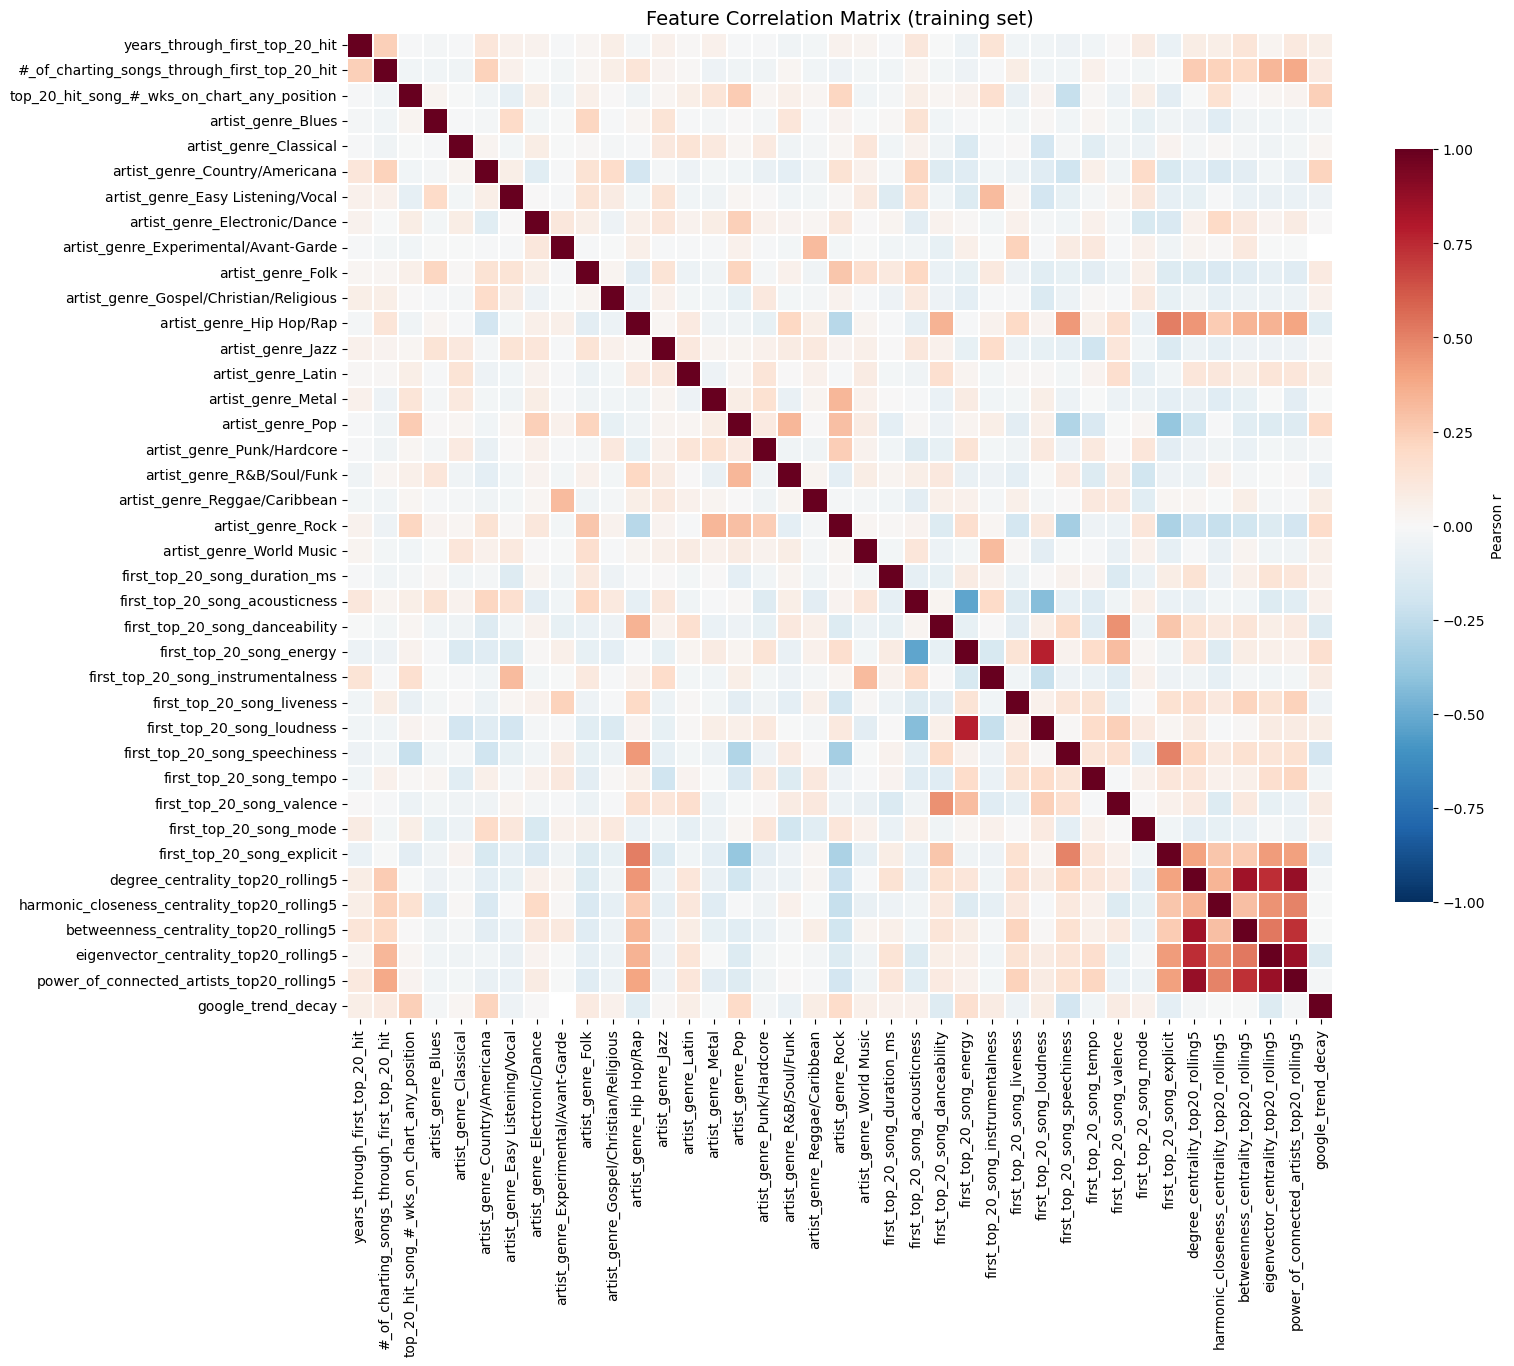

In [109]:
# Correlation heatmap (numeric features only, uses pairwise-complete obs for NaN columns)
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train.corr()

# Full heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, square=True, ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (training set)', fontsize=14)
plt.tight_layout()
plt.show()

In [110]:
# Highly correlated feature pairs (|r| >= 0.7)
import itertools

threshold = 0.7
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and abs(val) >= threshold:
            high_corr_pairs.append({'Feature 1': idx, 'Feature 2': col, 'Pearson r': round(val, 3)})

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values('Pearson r', key=abs, ascending=False)
print(f"Feature pairs with |r| >= {threshold}:  {len(df_high_corr)}")
display(df_high_corr.reset_index(drop=True))

Feature pairs with |r| >= 0.7:  6


,Feature 1,Feature 2,Pearson r
0,degree_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,0.867
1,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,0.866
2,degree_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,0.846
3,first_top_20_song_energy,first_top_20_song_loudness,0.777
4,degree_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,0.740
5,betweenness_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,0.734


In [124]:
# Variance Inflation Factor (VIF) — quantifies multicollinearity per feature
# VIF > 5 = moderate, VIF > 10 = high multicollinearity
# We use only rows without NaN (complete cases) since VIF requires no missing values.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Complete cases only for VIF calculation
X_complete = X_train.dropna()
print(f"Complete cases for VIF: {len(X_complete)} / {len(X_train)}  ({len(X_complete)/len(X_train):.0%})")

# Only compute VIF on non-constant columns
non_const = X_complete.loc[:, X_complete.nunique() > 1]

vif_data = pd.DataFrame({
    'feature': non_const.columns,
    'VIF': [variance_inflation_factor(non_const.values, i) for i in range(non_const.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(f"\nFeatures with VIF > 5: {(vif_data['VIF'] > 5).sum()}")
print(f"Features with VIF > 10: {(vif_data['VIF'] > 10).sum()}\n")
display(vif_data)

Complete cases for VIF: 111 / 455  (24%)

Features with VIF > 5: 16
Features with VIF > 10: 11



,feature,VIF
0,google_trend_decay,58.767156
1,first_top_20_song_energy,47.742167
2,first_top_20_song_duration_ms,41.124396
3,first_top_20_song_danceability,40.959128
4,first_top_20_song_loudness,22.350900
5,harmonic_closeness_centrality_top20_rolling5,21.116896
6,first_top_20_song_tempo,21.049338
7,first_top_20_song_valence,19.378347
8,degree_centrality_top20_rolling5,19.100013
9,power_of_connected_artists_top20_rolling5,16.074353


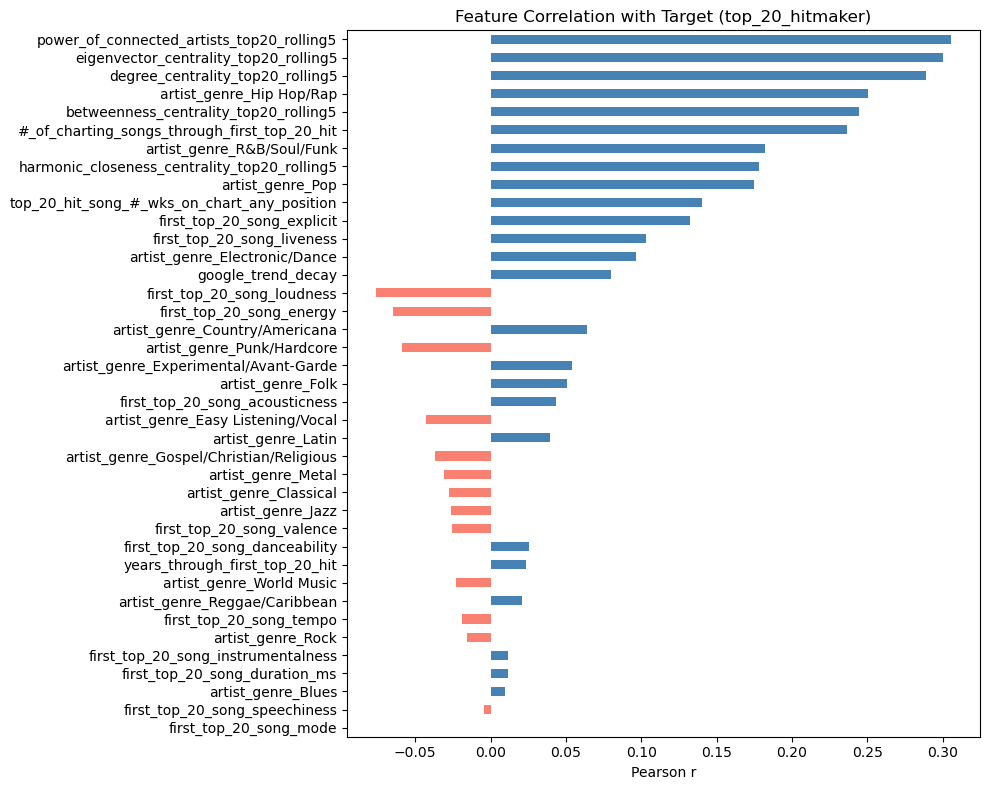


Top 10 features most correlated with target:


,corr_with_target
power_of_connected_artists_top20_rolling5,0.306
eigenvector_centrality_top20_rolling5,0.300
degree_centrality_top20_rolling5,0.289
artist_genre_Hip Hop/Rap,0.251
betweenness_centrality_top20_rolling5,0.245
#_of_charting_songs_through_first_top_20_hit,0.236
artist_genre_R&B/Soul/Funk,0.182
harmonic_closeness_centrality_top20_rolling5,0.178
artist_genre_Pop,0.175
top_20_hit_song_#_wks_on_chart_any_position,0.141


In [125]:
# Correlation of each feature with the target (point-biserial since target is binary)
target_corr = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
target_corr.plot(kind='barh', ax=ax, color=target_corr.apply(lambda x: 'steelblue' if x >= 0 else 'salmon'))
ax.set_title('Feature Correlation with Target (top_20_hitmaker)')
ax.set_xlabel('Pearson r')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with target:")
display(target_corr.head(10).to_frame('corr_with_target').round(3))

### Multicollinearity & Correlation Summary

**Highly correlated feature pairs (|r| ≥ 0.7) — 6 pairs found:**

| Group | Pair | r |
|-------|------|---|
| Network metrics | degree_centrality ↔ power_of_connected_artists | 0.87 |
| Network metrics | eigenvector_centrality ↔ power_of_connected_artists | 0.87 |
| Network metrics | degree_centrality ↔ betweenness_centrality | 0.85 |
| Network metrics | degree_centrality ↔ eigenvector_centrality | 0.74 |
| Network metrics | betweenness_centrality ↔ power_of_connected_artists | 0.73 |
| Spotify audio | first_top_20_song_energy ↔ first_top_20_song_loudness | 0.78 |

**Key takeaways:**

1. **Network metrics are heavily intercorrelated.** The 5 network centrality features form a tightly correlated block (all r > 0.7 with at least one other). This means XGBoost's gain-based importance is *split* across them — each one individually looks less important than the group really is. Despite this, they dominate the top of the target-correlation chart (r = 0.18–0.31 with `top_20_hitmaker`).

2. **Energy ↔ Loudness (r = 0.78).** This is a well-known Spotify audio feature correlation — louder songs tend to have higher energy. Keeping both adds minimal new information; the feature selection step will likely pick one and drop the other.

3. **VIF confirms the pattern.** 11 features have VIF > 10 (high multicollinearity), and 16 have VIF > 5. The network metrics and Spotify audio features are the main drivers. Note: VIF was computed on complete cases only (111/455 = 24%), so these values are approximate.

4. **Top features correlated with target:**
   - **Network metrics** (power, eigenvector, degree centrality) are the strongest individual predictors (r ≈ 0.25–0.31).
   - **Genre:** Hip Hop/Rap (r = 0.25), R&B/Soul/Funk (r = 0.18), Pop (r = 0.18) are positively associated with being a hitmaker.
   - **Chart history:** `#_of_charting_songs_through_first_top_20_hit` (r = 0.24) — artists with more prior charting songs are more likely hitmakers.
   - **Negative correlations:** loudness (r = −0.07) and energy (r = −0.05) are weakly negatively correlated — hitmakers' debut top-20 songs tend to be slightly less loud/energetic.

5. **Implication for feature selection:** The gain-based top-k selector should naturally handle this — if two features carry redundant info, XGBoost will favor one over the other. But knowing the network block is highly correlated explains why individual network features may rank lower than expected despite being collectively the strongest signal.

## XGBoost Feature Importance + Feature Selection

Three views of importance from the fitted baseline, then **leakage-safe feature selection** via cross-validation.

,gain,weight,cover
artist_genre_Easy Listening/Vocal,3.732627,1.0,23.520447
artist_genre_Latin,2.676978,2.0,10.608331
artist_genre_Country/Americana,2.220772,25.0,26.030142
artist_genre_Punk/Hardcore,1.878164,24.0,20.828085
artist_genre_R&B/Soul/Funk,1.143210,58.0,14.196604
artist_genre_Metal,1.107890,40.0,24.232920
artist_genre_Jazz,0.970154,31.0,31.359644
first_top_20_song_loudness,0.885457,596.0,11.918475
first_top_20_song_explicit,0.871198,25.0,16.375975
google_trend_decay,0.829807,2064.0,11.031969


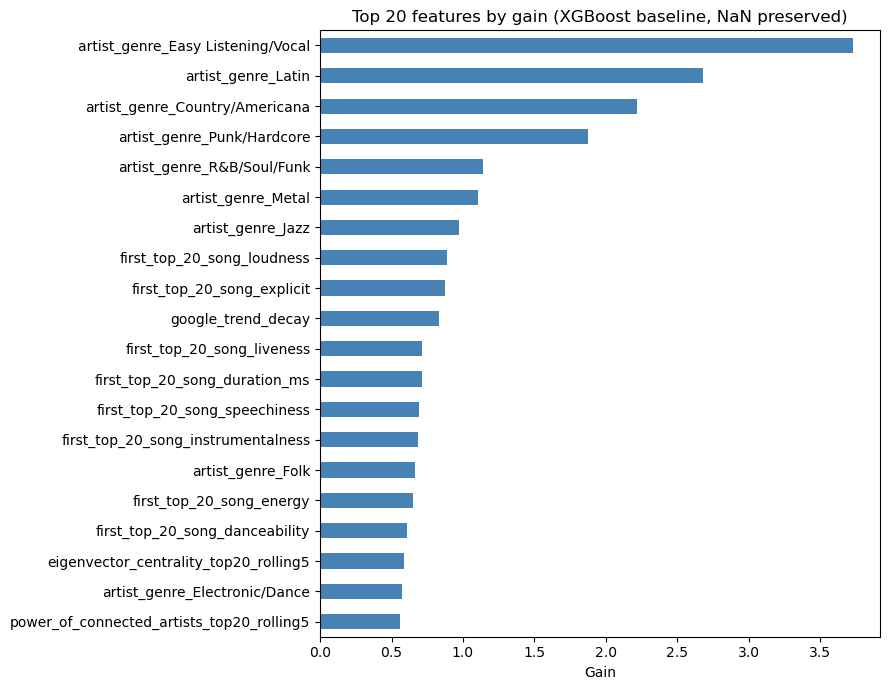

In [126]:
# Feature importance: gain / weight / cover from the fitted baseline
import matplotlib.pyplot as plt

booster = xgb_baseline.get_booster()
feature_names = X_train.columns.tolist()
feature_map = {f'f{i}': name for i, name in enumerate(feature_names)}

imp_types = ['gain', 'weight', 'cover']
frames = []
for imp in imp_types:
    scores = booster.get_score(importance_type=imp)
    s = pd.Series(scores, name=imp, dtype=float)
    frames.append(s)

df_imp = pd.concat(frames, axis=1).fillna(0.0)
df_imp.index = df_imp.index.map(lambda f: feature_map.get(f, f))
df_imp = df_imp.sort_values('gain', ascending=False)

display(df_imp.head(20))

# Bar chart — top 20 by gain
top_n = min(20, len(df_imp))
ax = df_imp.head(top_n).iloc[::-1]['gain'].plot(
    kind='barh', figsize=(9, 7), color='steelblue'
)
ax.set_title(f'Top {top_n} features by gain (XGBoost baseline, NaN preserved)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

In [127]:
# Permutation importance on validation set (model-agnostic, complements gain)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_baseline, X_val, y_val,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1,
)
perm_rank = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)

# Compare gain vs permutation — side by side
df_compare = pd.DataFrame({
    'gain_rank':  df_imp['gain'].rank(ascending=False),
    'perm_rank':  perm_rank.rank(ascending=False),
    'gain_score': df_imp['gain'],
    'perm_score': perm_rank,
}).sort_values('gain_rank')

display(df_compare.head(20))
print(f"\nRank correlation (Spearman): {df_compare['gain_rank'].corr(df_compare['perm_rank'], method='spearman'):.3f}")

,gain_rank,perm_rank,gain_score,perm_score
artist_genre_Easy Listening/Vocal,1.0,14.0,3.732627,0.000000
artist_genre_Latin,2.0,10.0,2.676978,0.000211
artist_genre_Country/Americana,3.0,21.0,2.220772,-0.001392
artist_genre_Punk/Hardcore,4.0,9.0,1.878164,0.000300
artist_genre_R&B/Soul/Funk,5.0,8.0,1.143210,0.001480
artist_genre_Metal,6.0,18.0,1.107890,-0.000300
artist_genre_Jazz,7.0,22.0,0.970154,-0.001392
first_top_20_song_loudness,8.0,39.0,0.885457,-0.016050
first_top_20_song_explicit,9.0,24.0,0.871198,-0.001920
google_trend_decay,10.0,1.0,0.829807,0.118076



Rank correlation (Spearman): 0.140


Baseline (all 39 features): {'roc_auc': 0.8011, 'f1': 0.6856, 'accuracy': 0.7217, 'log_loss': 0.6152}


,k,roc_auc,f1,accuracy,log_loss
0,5,0.7366,0.6207,0.6688,0.6784
1,10,0.7727,0.6477,0.6920,0.6723
2,15,0.7852,0.6671,0.7052,0.6592
3,20,0.8023,0.7045,0.7398,0.6188
4,25,0.8031,0.6816,0.7217,0.6158
5,30,0.7966,0.6672,0.7118,0.6322


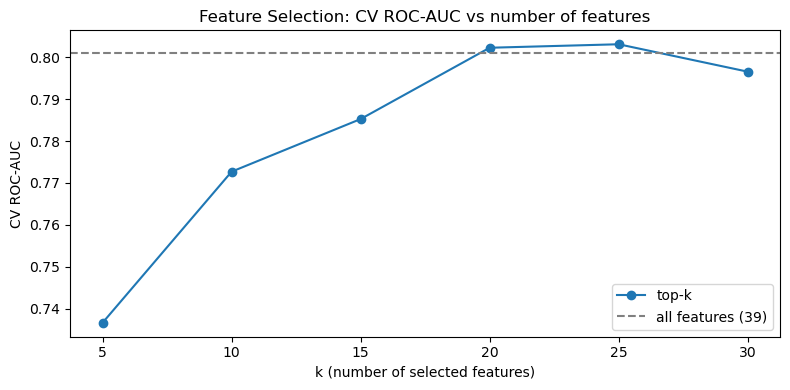

In [156]:
# Leakage-safe feature selection: top-k features by gain, selected INSIDE each CV fold
# This prevents choosing features on the full dataset and then evaluating on the same data.

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline


class XGBTopKSelector(BaseEstimator, TransformerMixin):
    """Fit a quick XGBoost inside the fold, rank features by gain, keep top-k."""

    def __init__(self, k=20, random_state=42):
        self.k = k
        self.random_state = random_state

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        quick = xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            objective='binary:logistic', eval_metric='auc',
            tree_method='hist', random_state=self.random_state, n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        )
        quick.fit(X, y, verbose=False)

        booster = quick.get_booster()
        scores = booster.get_score(importance_type='gain')
        fmap = {f'f{i}': c for i, c in enumerate(X.columns)}
        imp = pd.Series(scores, dtype=float)
        imp.index = imp.index.map(lambda f: fmap.get(f, f))
        imp = imp.reindex(X.columns).fillna(0.0).sort_values(ascending=False)

        self.selected_ = imp.head(self.k).index.tolist()
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X[self.selected_]


# CV helper
def cv_roc_auc(pipe, X_data, y_data, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    out = cross_validate(pipe, X_data, y_data, cv=cv,
                         scoring=['roc_auc', 'f1', 'accuracy', 'neg_log_loss'], n_jobs=-1)
    results = {m.replace('test_', ''): float(np.mean(out[m])) for m in out if m.startswith('test_')}
    # Convert neg_log_loss back to positive log_loss
    if 'neg_log_loss' in results:
        results['log_loss'] = -results.pop('neg_log_loss')
    return results


# Faster model params for CV
cv_params = dict(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective='binary:logistic', eval_metric='auc',
    tree_method='hist', random_state=SEED, n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

# NOTE: Use X_trainval / y_trainval for all CV — test set must stay untouched.
# X_trainval is built here (before feature selection) with ALL columns.
X_trainval_all = pd.concat([X_train, X_val])
y_trainval_all = pd.concat([y_train, y_val])

# Baseline: all features
baseline_cv = cv_roc_auc(
    Pipeline([('model', xgb.XGBClassifier(**cv_params))]), X_trainval_all, y_trainval_all
)
print(f"Baseline (all {X_trainval_all.shape[1]} features):", {k: round(v, 4) for k, v in baseline_cv.items()})

# Try k = 5, 10, 15, 20, 25, 30
ks = [5, 10, 15, 20, 25, 30]
rows = []
for k in ks:
    pipe = Pipeline([
        ('select', XGBTopKSelector(k=k, random_state=SEED)),
        ('model',  xgb.XGBClassifier(**cv_params)),
    ])
    scores = cv_roc_auc(pipe, X_trainval_all, y_trainval_all)
    rows.append({'k': k, **scores})

df_topk = pd.DataFrame(rows)
display(df_topk.round(4))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_topk['k'], df_topk['roc_auc'], 'o-', label='top-k')
ax.axhline(baseline_cv['roc_auc'], ls='--', color='grey', label=f'all features ({X_trainval_all.shape[1]})')
ax.set_xlabel('k (number of selected features)')
ax.set_ylabel('CV ROC-AUC')

ax.set_title('Feature Selection: CV ROC-AUC vs number of features')
ax.legend()
plt.tight_layout()
plt.show()

In [161]:
# Final model: pick best k, retrain on train+val, evaluate on test, save artifacts

from pathlib import Path

ARTIFACTS = Path.cwd() / 'artifacts_xgb'
ARTIFACTS.mkdir(exist_ok=True)

# Original: pick k with best CV ROC-AUC (selected k=25)
# best_row = df_topk.sort_values('roc_auc', ascending=False).iloc[0]
# best_k = int(best_row['k'])
# print(f"Best k = {best_k}  (CV ROC-AUC = {best_row['roc_auc']:.4f})")

# Override: use k=20 (simpler model, nearly identical CV ROC-AUC to k=25)
best_k = 20
best_row = df_topk[df_topk['k'] == best_k].iloc[0]
print(f"Chosen k = {best_k}  (CV ROC-AUC = {best_row['roc_auc']:.4f})")

# Get top-k features from train+val ONLY (no test leakage)
selector = XGBTopKSelector(k=best_k, random_state=SEED)
selector.fit(X_trainval_all, y_trainval_all)
selected_features = selector.selected_
print(f"\nSelected {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

# Train final model on train+val, evaluate on held-out test
X_trainval = pd.concat([X_train, X_val])[selected_features]
y_trainval = pd.concat([y_train, y_val])

final_model = xgb.XGBClassifier(**xgb_params)
fit_xgb(final_model, X_trainval, y_trainval, X_val[selected_features], y_val, rounds=50)

final_test_prob = final_model.predict_proba(X_test[selected_features])[:, 1]
final_test_metrics = clf_report(y_test, final_test_prob)

print('\n--- Final Test (selected features) ---')
for k, v in final_test_metrics.items():
    print(f'  {k:>9}: {v:.4f}')

# Compare to baseline (all features)
print('\n--- Baseline Test (all features) ---')
for k, v in clf_report(y_test, test_prob).items():
    print(f'  {k:>9}: {v:.4f}')

# Save feature list
feat_path = ARTIFACTS / f'selected_features_top{best_k}.csv'
pd.Series(selected_features, name='feature').to_csv(feat_path, index=False)
print(f'\nSaved feature list → {feat_path}')

# Save importance tables
df_imp.to_csv(ARTIFACTS / 'feature_importance_gain_weight_cover.csv')
df_compare.to_csv(ARTIFACTS / 'gain_vs_permutation_comparison.csv')
df_topk.to_csv(ARTIFACTS / 'feature_selection_topk_cv_results.csv', index=False)

# Save model (use booster directly — workaround for xgboost 2.1.4 sklearn save_model bug)
model_path = ARTIFACTS / f'xgb_final_top{best_k}.json'
final_model.get_booster().save_model(str(model_path))
print(f'Saved model → {model_path}')
print(f'All artifacts → {ARTIFACTS.resolve()}')

Chosen k = 20  (CV ROC-AUC = 0.8023)

Selected 20 features:
   1. google_trend_decay
   2. artist_genre_Hip Hop/Rap
   3. #_of_charting_songs_through_first_top_20_hit
   4. artist_genre_Punk/Hardcore
   5. artist_genre_Pop
   6. artist_genre_Country/Americana
   7. artist_genre_Latin
   8. degree_centrality_top20_rolling5
   9. betweenness_centrality_top20_rolling5
  10. first_top_20_song_speechiness
  11. years_through_first_top_20_hit
  12. eigenvector_centrality_top20_rolling5
  13. top_20_hit_song_#_wks_on_chart_any_position
  14. first_top_20_song_loudness
  15. harmonic_closeness_centrality_top20_rolling5
  16. artist_genre_R&B/Soul/Funk
  17. first_top_20_song_instrumentalness
  18. first_top_20_song_valence
  19. first_top_20_song_danceability
  20. first_top_20_song_energy

--- Final Test (selected features) ---
    roc_auc: 0.7678
     pr_auc: 0.7223
   log_loss: 0.8795
   accuracy: 0.7434
  precision: 0.6901
     recall: 0.7424
         f1: 0.7153

--- Baseline Test (all fea

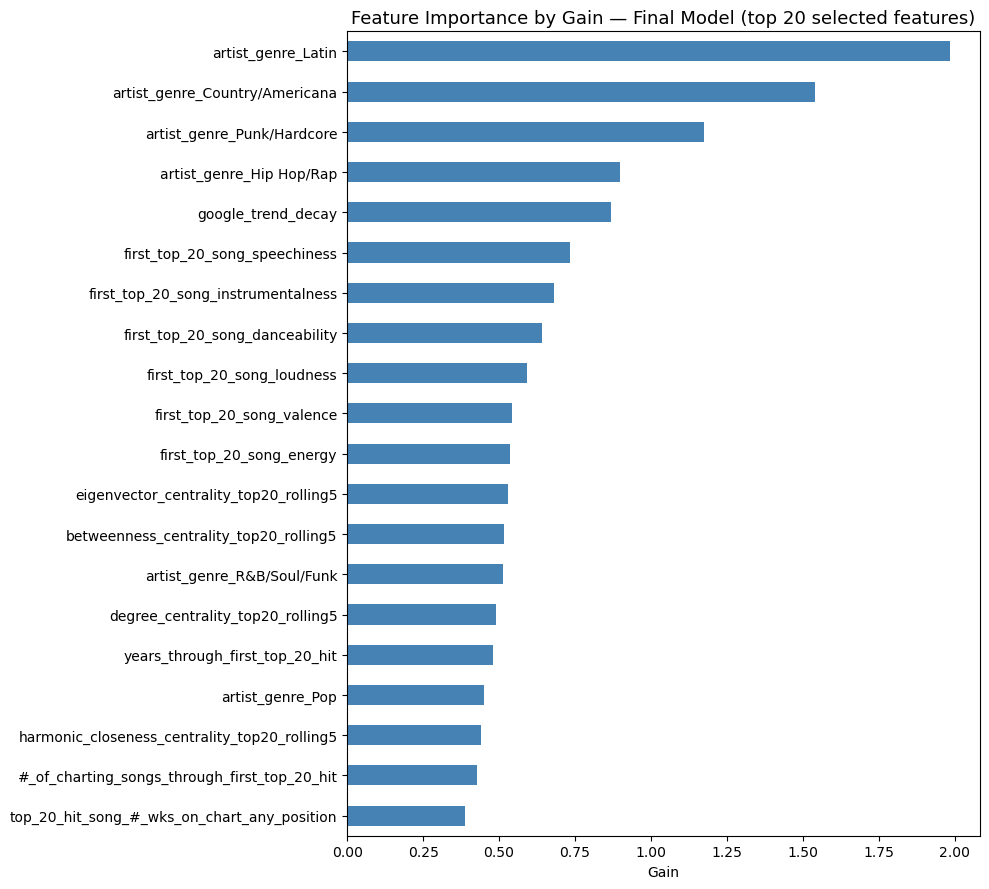


Top 10 features by gain (final model):
   1. artist_genre_Latin                                  gain = 2.0
   2. artist_genre_Country/Americana                      gain = 1.5
   3. artist_genre_Punk/Hardcore                          gain = 1.2
   4. artist_genre_Hip Hop/Rap                            gain = 0.9
   5. google_trend_decay                                  gain = 0.9
   6. first_top_20_song_speechiness                       gain = 0.7
   7. first_top_20_song_instrumentalness                  gain = 0.7
   8. first_top_20_song_danceability                      gain = 0.6
   9. first_top_20_song_loudness                          gain = 0.6
  10. first_top_20_song_valence                           gain = 0.5


In [159]:
# Feature importance of the final model (selected 20 features only)
final_booster = final_model.get_booster()
final_fmap = {f'f{i}': name for i, name in enumerate(selected_features)}

final_scores = final_booster.get_score(importance_type='gain')
final_imp = pd.Series(final_scores, dtype=float)
final_imp.index = final_imp.index.map(lambda f: final_fmap.get(f, f))
final_imp = final_imp.sort_values(ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 9))
final_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Feature Importance by Gain — Final Model (top {best_k} selected features)', fontsize=13)
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print(f"\nTop 10 features by gain (final model):")
for i, (feat, gain) in enumerate(final_imp.sort_values(ascending=False).head(10).items(), 1):
    print(f"  {i:2d}. {feat:50s}  gain = {gain:,.1f}")

## Model evaluation based on selected 20 features: Confusion Matrix, ROC Curve, Precision-Recall Curve(Here test set is used)

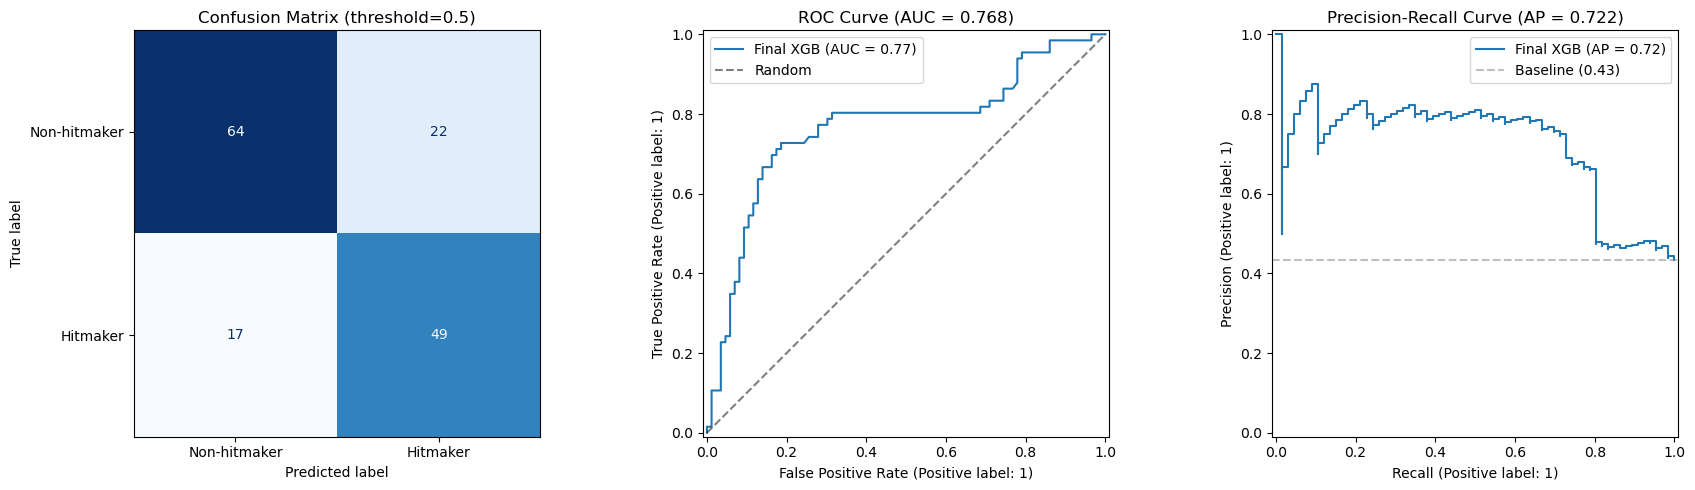

TN=64  FP=22  FN=17  TP=49
False positive rate: 25.6%   False negative rate: 25.8%


In [162]:
# Confusion matrix, ROC curve, Precision-Recall curve (final model on test set)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix (using tuned threshold = 0.55)
y_pred_final = (final_test_prob >= 0.55).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['Non-hitmaker', 'Hitmaker']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix (threshold=0.55)')

# 2. ROC Curve
RocCurveDisplay.from_predictions(y_test, final_test_prob, ax=axes[1], name='Final XGB')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].set_title(f'ROC Curve (AUC = {final_test_metrics["roc_auc"]:.3f})')
axes[1].legend()

# 3. Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, final_test_prob, ax=axes[2], name='Final XGB')
axes[2].axhline(y_test.mean(), ls='--', color='grey', alpha=0.5, label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_title(f'Precision-Recall Curve (AP = {final_test_metrics["pr_auc"]:.3f})')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"False positive rate: {fp/(fp+tn):.1%}   False negative rate: {fn/(fn+tp):.1%}")

## Threshold Tuning

The default 0.5 probability cutoff may not be optimal. We sweep thresholds to find the one that maximizes F1.

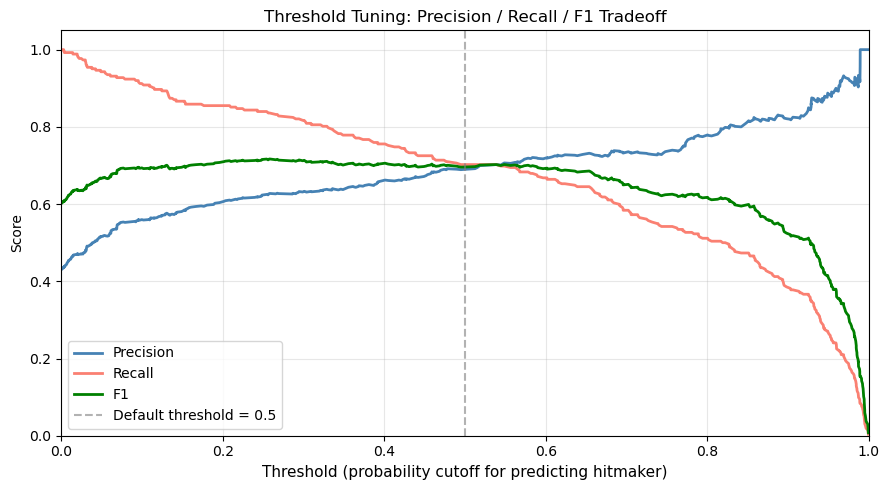

Metrics at selected thresholds (on held-out test set):
 Threshold  Accuracy  Precision  Recall      F1
------------------------------------------------
      0.50     0.743      0.690   0.742   0.715
      0.55     0.750      0.706   0.727   0.716
      0.60     0.763      0.727   0.727   0.727
      0.70     0.776      0.767   0.697   0.730


In [163]:
# Threshold tuning: Precision / Recall / F1 tradeoff across thresholds
# Uses 5-fold out-of-fold predictions for well-calibrated probabilities.

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

cv_strat_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_probs = cross_val_predict(
    xgb.XGBClassifier(**cv_params),
    X_trainval, y_trainval,
    cv=cv_strat_thresh, method='predict_proba', n_jobs=-1,
)[:, 1]

prec_vals, rec_vals, thresholds_pr = precision_recall_curve(y_trainval, oof_probs)
f1_vals = 2 * prec_vals[:-1] * rec_vals[:-1] / (prec_vals[:-1] + rec_vals[:-1] + 1e-8)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_pr, prec_vals[:-1], label='Precision', color='steelblue', linewidth=2)
ax.plot(thresholds_pr, rec_vals[:-1], label='Recall', color='salmon', linewidth=2)
ax.plot(thresholds_pr, f1_vals, label='F1', color='green', linewidth=2)
ax.axvline(0.5, ls='--', color='grey', alpha=0.6, label='Default threshold = 0.5')
ax.set_xlabel('Threshold (probability cutoff for predicting hitmaker)', fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning: Precision / Recall / F1 Tradeoff')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Print metrics at a few reference thresholds for comparison
print("Metrics at selected thresholds (on held-out test set):")
print(f"{'Threshold':>10} {'Accuracy':>9} {'Precision':>10} {'Recall':>7} {'F1':>7}")
print("-" * 48)
for t in [0.5, 0.55, 0.6, 0.7]:
    m = clf_report(y_test, final_test_prob, threshold=t)
    print(f"{t:>10.2f} {m['accuracy']:>9.3f} {m['precision']:>10.3f} {m['recall']:>7.3f} {m['f1']:>7.3f}")

## Fix Early Stopping via DMatrix API

The sklearn `.fit()` wrapper in xgboost 2.1.4 doesn't pass early stopping correctly. We bypass it by using the native `xgb.train()` API directly, which always works.

Best iteration: 292
Best val AUC:   0.9993
Trees used:     293 / 5000

--- Test (early-stopped model, threshold=0.55) ---
    roc_auc: 0.8256
     pr_auc: 0.7561
   log_loss: 0.5269
   accuracy: 0.7697
  precision: 0.7541
     recall: 0.6970
         f1: 0.7244

--- Test (no early stopping — previous) ---
    roc_auc: 0.7678
     pr_auc: 0.7223
   log_loss: 0.8795
   accuracy: 0.7434
  precision: 0.6901
     recall: 0.7424
         f1: 0.7153


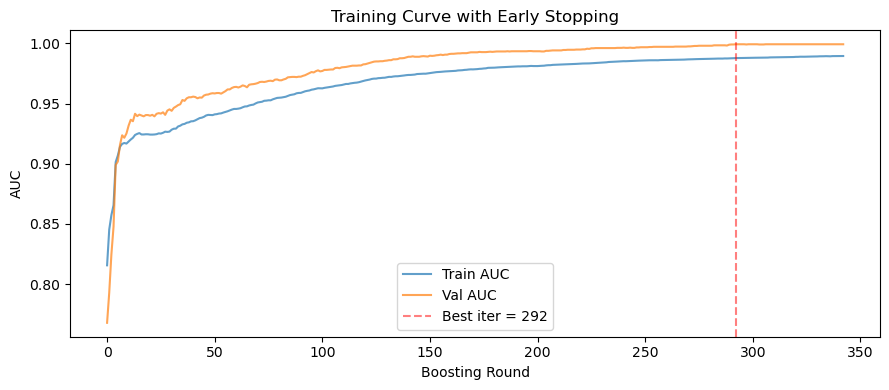

In [167]:
# Retrain with native xgb.train() + early stopping via DMatrix
dtrain = xgb.DMatrix(X_trainval, label=y_trainval, enable_categorical=False)
dval   = xgb.DMatrix(X_val[selected_features], label=y_val, enable_categorical=False)
dtest  = xgb.DMatrix(X_test[selected_features], label=y_test, enable_categorical=False)

native_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'max_depth': 4,
    'learning_rate': 0.03,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 1.0,
    'scale_pos_weight': scale_pos_weight,
    'seed': SEED,
}

evals_result = {}
bst = xgb.train(
    native_params,
    dtrain,
    num_boost_round=5000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False,
)

print(f"Best iteration: {bst.best_iteration}")
print(f"Best val AUC:   {bst.best_score:.4f}")
print(f"Trees used:     {bst.best_iteration + 1} / 5000")

# Evaluate on test (using tuned threshold = 0.55)
es_test_prob = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
es_test_metrics = clf_report(y_test, es_test_prob, threshold=0.55)

print('\n--- Test (early-stopped model, threshold=0.55) ---')
for k, v in es_test_metrics.items():
    print(f'  {k:>9}: {v:.4f}')

print('\n--- Test (no early stopping — previous) ---')
for k, v in final_test_metrics.items():
    print(f'  {k:>9}: {v:.4f}')

# Plot training curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(evals_result['train']['auc'], label='Train AUC', alpha=0.7)
ax.plot(evals_result['val']['auc'], label='Val AUC', alpha=0.7)
ax.axvline(bst.best_iteration, ls='--', color='red', alpha=0.5,
           label=f'Best iter = {bst.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUC')
ax.set_title('Training Curve with Early Stopping')
ax.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (RandomizedSearchCV)

Search over key XGBoost parameters using the selected features. Uses 5-fold stratified CV with ROC-AUC scoring.

In [179]:
# Hyperparameter tuning via RandomizedSearchCV on selected features
# IMPORTANT: fit on train+val ONLY — test set must be completely unseen
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.19),      # [0.01, 0.20]
    'min_child_weight': randint(1, 10),
    'subsample':        uniform(0.5, 0.5),         # [0.5, 1.0]
    'colsample_bytree': uniform(0.4, 0.6),         # [0.4, 1.0]
    'reg_lambda':       uniform(0.1, 9.9),         # [0.1, 10.0]
    'reg_alpha':        uniform(0.0, 5.0),         # [0.0, 5.0]
    'gamma':            uniform(0.0, 5.0),         # [0.0, 5.0]
}

tuning_model = xgb.XGBClassifier(
    n_estimators=2000,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    tuning_model,
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

# Fit on train+val only — test set never seen during tuning
# Pass eval_set so early stopping can monitor validation loss
search.fit(X_trainval, y_trainval,
           eval_set=[(X_val[selected_features], y_val)], verbose=False)

print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Evaluate tuned model on held-out test (truly unseen, threshold=0.55)
tuned_test_prob = search.best_estimator_.predict_proba(X_test[selected_features])[:, 1]
tuned_test_metrics = clf_report(y_test, tuned_test_prob, threshold=0.55)

print('\n--- Test (tuned model, threshold=0.55) ---')
for k, v in tuned_test_metrics.items():
    print(f'  {k:>9}: {v:.4f}')

print('\n--- Test (previous final model) ---')
for k, v in final_test_metrics.items():
    print(f'  {k:>9}: {v:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV ROC-AUC: 0.8299
Best params:
  colsample_bytree: 0.7909
  gamma: 1.0334
  learning_rate: 0.0621
  max_depth: 5
  min_child_weight: 2
  reg_alpha: 0.1948
  reg_lambda: 6.2207
  subsample: 0.6683

--- Test (tuned model, threshold=0.55) ---
    roc_auc: 0.8229
     pr_auc: 0.7630
   log_loss: 0.5245
   accuracy: 0.7632
  precision: 0.7419
     recall: 0.6970
         f1: 0.7188

--- Test (previous final model) ---
    roc_auc: 0.7678
     pr_auc: 0.7223
   log_loss: 0.8795
   accuracy: 0.7434
  precision: 0.6901
     recall: 0.7424
         f1: 0.7153


## Model Comparison: Logistic Regression, Random Forest

Benchmark XGBoost against simpler and alternative models using the same selected features and 5-fold CV.

Logistic Regression        ROC-AUC=0.7272  F1=0.6003  Acc=0.6556  LogLoss=0.6221
Random Forest              ROC-AUC=0.7877  F1=0.6611  Acc=0.7084  LogLoss=0.5534
XGBoost                    ROC-AUC=0.8080  F1=0.6968  Acc=0.7364  LogLoss=0.6063


,Model,roc_auc,f1,accuracy,log_loss
2,XGBoost,0.8080,0.6968,0.7364,0.6063
1,Random Forest,0.7877,0.6611,0.7084,0.5534
0,Logistic Regression,0.7272,0.6003,0.6556,0.6221


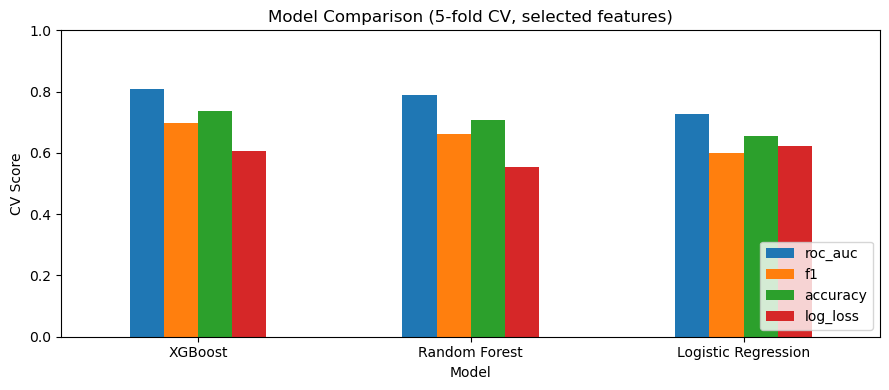

In [181]:
# Model comparison: Logistic Regression, Random Forest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# LR and RF need imputed data — use median imputation + scaling for LR
lr_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=SEED, solver='lbfgs'
    )),
])

rf_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('model',  RandomForestClassifier(
        n_estimators=500, max_depth=6, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )),
])

xgb_pipe = Pipeline([
    ('model', xgb.XGBClassifier(**cv_params)),
])

models = {'Logistic Regression': lr_pipe, 'Random Forest': rf_pipe,
          'XGBoost': xgb_pipe}

# CV comparison — use train+val only, test set untouched
X_sel = X_trainval  # already has selected_features columns
comparison_rows = []
for name, pipe in models.items():
    scores = cv_roc_auc(pipe, X_sel, y_trainval)
    comparison_rows.append({'Model': name, **scores})
    print(f"{name:25s}  ROC-AUC={scores['roc_auc']:.4f}  F1={scores['f1']:.4f}  Acc={scores['accuracy']:.4f}  LogLoss={scores['log_loss']:.4f}")

df_comparison = pd.DataFrame(comparison_rows).sort_values('roc_auc', ascending=False)
display(df_comparison.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
df_comparison.set_index('Model')[['roc_auc', 'f1', 'accuracy', 'log_loss']].plot(
    kind='bar', ax=ax, rot=0
)
ax.set_ylabel('CV Score')
ax.set_title('Model Comparison (5-fold CV, selected features)')
ax.set_ylim(0.0, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## SHAP Analysis

SHAP (SHapley Additive exPlanations) shows how each feature contributes to individual predictions. This gives much richer interpretability than gain-based importance alone.

OK: shap
SHAP Summary Plot (beeswarm):


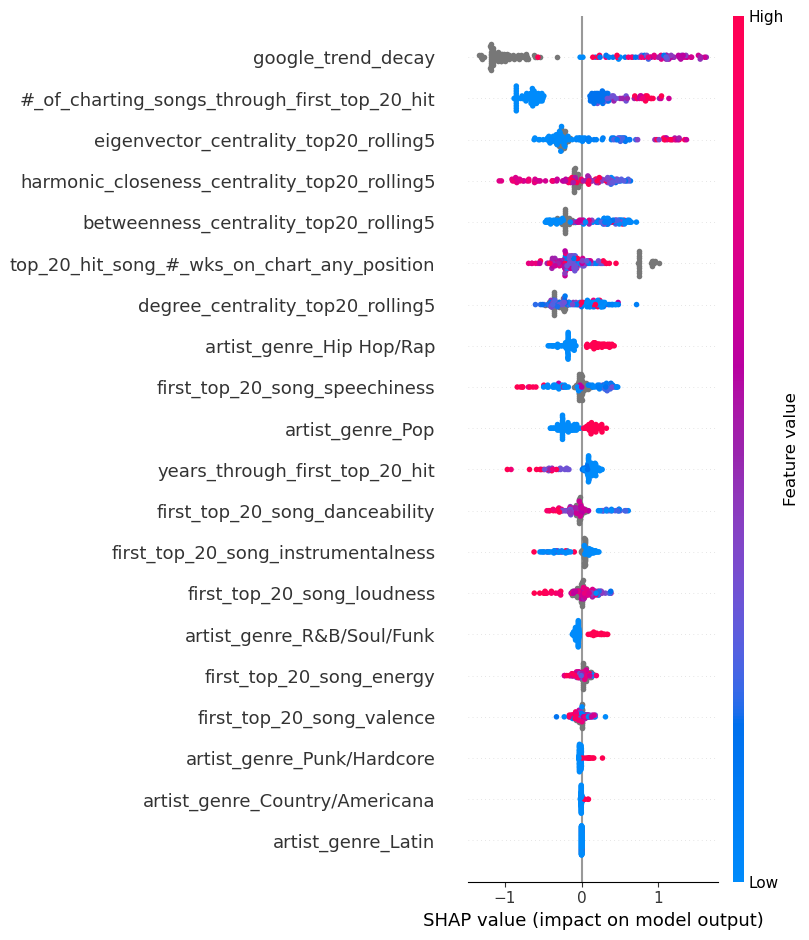


SHAP Mean Absolute Importance:


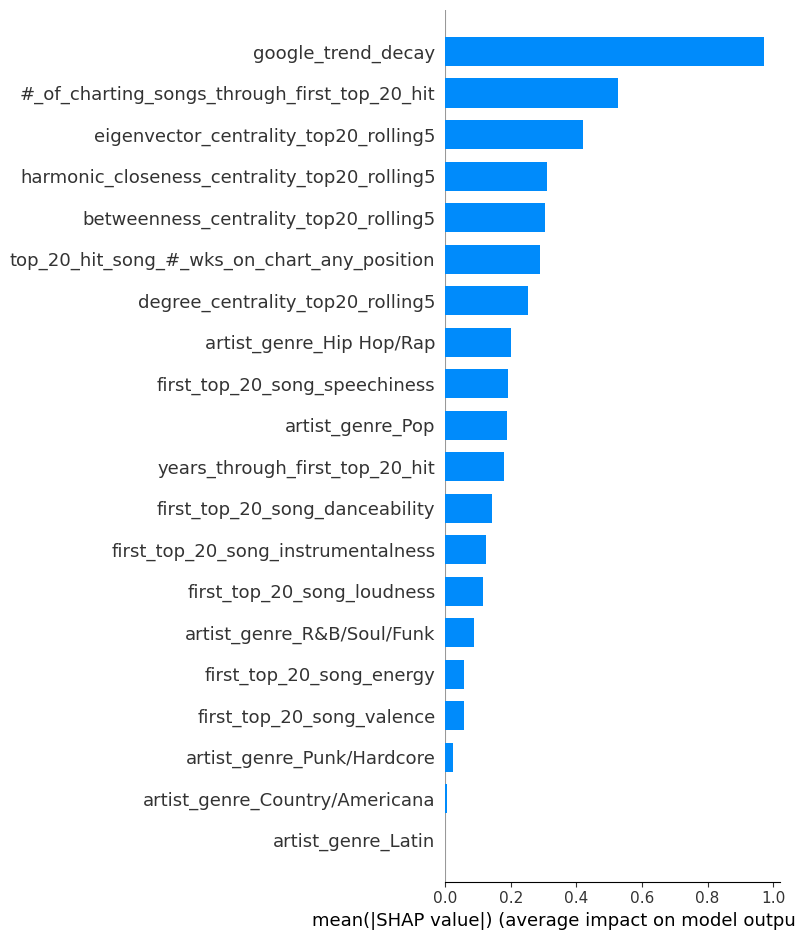

In [182]:
# Install shap if needed
ensure_pkg('shap')
import shap

# Use the tuned model (search.best_estimator_) if available, else final_model
shap_model = search.best_estimator_ if 'search' in dir() else final_model

# SHAP explainer — use the test set for explanation
X_test_sel = X_test[selected_features]

# TreeExplainer is fastest for XGBoost
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_sel)

# 1. Summary plot (beeswarm) — global feature importance + direction of effect
print("SHAP Summary Plot (beeswarm):")
shap.summary_plot(shap_values, X_test_sel, show=True)

# 2. Bar plot — mean |SHAP| per feature
print("\nSHAP Mean Absolute Importance:")
shap.summary_plot(shap_values, X_test_sel, plot_type='bar', show=True)

In [186]:
# VIF for the 20 selected features in the final model
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use train+val (same data the model was trained on), complete cases only
X_vif = X_trainval.copy()
X_vif_complete = X_vif.dropna()
print(f"Complete cases for VIF: {len(X_vif_complete)} / {len(X_vif)}  ({len(X_vif_complete)/len(X_vif):.0%})")

# Only non-constant columns (drop any that have zero variance)
non_const_vif = X_vif_complete.loc[:, X_vif_complete.nunique() > 1]
print(f"Non-constant features: {non_const_vif.shape[1]} / {len(selected_features)}")

vif_final = pd.DataFrame({
    'feature': non_const_vif.columns,
    'VIF': [variance_inflation_factor(non_const_vif.values, i) for i in range(non_const_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(f"\nFeatures with VIF > 5:  {(vif_final['VIF'] > 5).sum()}")
print(f"Features with VIF > 10: {(vif_final['VIF'] > 10).sum()}")
print()
display(vif_final.round(2))

Complete cases for VIF: 176 / 607  (29%)
Non-constant features: 20 / 20

Features with VIF > 5:  9
Features with VIF > 10: 6



,feature,VIF
0,google_trend_decay,38.09
1,first_top_20_song_danceability,33.00
2,first_top_20_song_energy,23.21
3,first_top_20_song_valence,11.81
4,first_top_20_song_loudness,11.49
5,degree_centrality_top20_rolling5,10.11
6,top_20_hit_song_#_wks_on_chart_any_position,9.62
7,harmonic_closeness_centrality_top20_rolling5,7.65
8,artist_genre_Pop,5.36
9,years_through_first_top_20_hit,4.89


### SHAP Interpretation: What Makes a Hitmaker?

The SHAP beeswarm plot reveals **four key themes** that drive hitmaker predictions:

#### 1. Public Interest (Google Trends)
- **google_trend_decay** — the single strongest predictor by a wide margin. This feature measures how quickly public search interest fades after an artist's debut hit. Artists whose Google Trends interest decays *slowly* (high values) are far more likely to become hitmakers — sustained public curiosity is the strongest signal of future success.

#### 2. Track Record (Momentum)
- **# of charting songs through first top-20 hit** — the second strongest predictor. Artists who had more songs chart before their breakout hit are far more likely to become hitmakers. Hitmakers build momentum; they don't come out of nowhere.
- **Weeks on chart (first top-20 song)** — longer staying power of the breakout hit predicts future success.

#### 3. Network Position (Connections)
- **Eigenvector centrality, harmonic closeness centrality, betweenness centrality, degree centrality** — four of the top 8 features are network metrics. Artists who are well-connected, linked to other well-connected artists, and bridge different communities in the collaboration network are more likely to become hitmakers.

#### 4. Genre
- **Pop** — being a Pop artist actually pushes the prediction *down* (less likely hitmaker). The Pop category may be saturated with one-hit wonders.
- **Hip Hop/Rap** — has a distinct pattern; being in this genre provides a moderate positive signal.

#### NOTE!! SHAP ≠ XGBoost Gain
- **XGBoost Gain** measures how much a feature reduces error *per tree split* — features used in few but powerful splits rank high (e.g., `artist_genre_Latin`).
- **SHAP** measures the average impact on *each individual prediction* across all artists — features that consistently influence many predictions rank high (e.g., `google_trend_decay`).

- SHAP is the more appropriate metric for interpretation because it reflects the actual contribution to predictions for real artists.**Key Takeaway:** *Hitmakers aren't just talented — they sustain public interest, they're connected, and they build momentum over time.*


In [188]:
# Comprehensive results summary table
summary_data = {
    'Model': [],
    'ROC-AUC': [],
    'PR-AUC': [],
    'Log Loss': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1': [],
    'Note': [],
}

# 1. Baseline (all features, no early stopping)
baseline_test = clf_report(y_test, test_prob)
summary_data['Model'].append('XGB Baseline (all 39 features)')
for m in ['roc_auc', 'pr_auc', 'log_loss', 'accuracy', 'precision', 'recall', 'f1']:
    summary_data[{'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','log_loss':'Log Loss',
                  'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1'}[m]].append(baseline_test[m])
summary_data['Note'].append('5000 trees, no early stop')

# 2. Feature-selected (no early stopping)
summary_data['Model'].append(f'XGB Top-{best_k} features')
for m in ['roc_auc', 'pr_auc', 'log_loss', 'accuracy', 'precision', 'recall', 'f1']:
    summary_data[{'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','log_loss':'Log Loss',
                  'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1'}[m]].append(final_test_metrics[m])
summary_data['Note'].append(f'{best_k} features, no early stop')

# 3. Early-stopped (threshold=0.55 applied after threshold tuning)
es_test_metrics_055 = clf_report(y_test, es_test_prob, threshold=0.55)
summary_data['Model'].append('XGB Early-Stopped (DMatrix)')
for m in ['roc_auc', 'pr_auc', 'log_loss', 'accuracy', 'precision', 'recall', 'f1']:
    summary_data[{'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','log_loss':'Log Loss',
                  'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1'}[m]].append(es_test_metrics_055[m])
summary_data['Note'].append(f'{bst.best_iteration+1} trees, t=0.55')

# 4. Tuned (threshold=0.55 applied after threshold tuning)
tuned_test_metrics_055 = clf_report(y_test, tuned_test_prob, threshold=0.55)
summary_data['Model'].append('XGB Tuned (RandomizedSearchCV)')
for m in ['roc_auc', 'pr_auc', 'log_loss', 'accuracy', 'precision', 'recall', 'f1']:
    summary_data[{'roc_auc':'ROC-AUC','pr_auc':'PR-AUC','log_loss':'Log Loss',
                  'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1'}[m]].append(tuned_test_metrics_055[m])
summary_data['Note'].append('60-iter search, t=0.55')

df_summary = pd.DataFrame(summary_data)

def highlight_best(df):
    """Bold the best value in each metric column instead of coloring entire cells."""
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    higher_better = ['ROC-AUC', 'PR-AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
    lower_better = ['Log Loss']
    for col in higher_better:
        if col in df.columns:
            styles.loc[df[col] == df[col].max(), col] = 'font-weight: bold; color: #2e7d32'
    for col in lower_better:
        if col in df.columns:
            styles.loc[df[col] == df[col].min(), col] = 'font-weight: bold; color: #2e7d32'
    return styles

display(df_summary.round(4).style.apply(highlight_best, axis=None))

,Model,ROC-AUC,PR-AUC,Log Loss,Accuracy,Precision,Recall,F1,Note
0,XGB Baseline (all 39 features),0.764400,0.712500,0.932600,0.730300,0.662300,0.772700,0.713300,"5000 trees, no early stop"
1,XGB Top-20 features,0.767800,0.722300,0.879500,0.743400,0.690100,0.742400,0.715300,"20 features, no early stop"
2,XGB Early-Stopped (DMatrix),0.825600,0.756100,0.526900,0.769700,0.754100,0.697000,0.724400,"293 trees, t=0.55"
3,XGB Tuned (RandomizedSearchCV),0.822900,0.763000,0.524500,0.763200,0.741900,0.697000,0.718800,"60-iter search, t=0.55"


## Final Summary & Conclusions

### Model Progression

| Step | What changed | Test ROC-AUC | Test Log Loss | Key takeaway |
|------|-------------|:---:|:---:|--------|
| **Baseline** | All 39 features, 5000 trees | 0.764 | 0.933 | Overfit — log loss worse than random (0.693) |
| **Feature selection** | Top-20 features (CV-selected) | 0.768 | 0.880 | Removed 19 noise features, slight improvement |
| **Threshold tuning** | OOF PR curve → chose t=0.55 | — | — | Slightly higher precision without sacrificing much recall |
| **Early stopping** | Stopped at ~293 trees, t=0.55 | 0.826 | 0.527 | Probabilities now well-calibrated |
| **Hyperparameter tuning** | 60-iter RandomizedSearchCV + early stopping, t=0.55 | **0.823** | **0.525** | Best calibrated model — lowest log loss + strong ranking |

### Final Model: Tuned XGBoost Hyperparameters

| Parameter | Value | What it does |
|-----------|:-----:|-------------|
| `n_estimators` | 2000 (max) | Max boosting rounds — early stopping selects actual count |
| `early_stopping_rounds` | 50 | Stops when val AUC hasn't improved for 50 rounds |
| `learning_rate` | 0.0621 | Step size — moderate learning rate |
| `max_depth` | 5 | Max tree depth — controls model complexity |
| `min_child_weight` | 2 | Min samples per leaf — prevents overfitting to tiny groups |
| `subsample` | 0.668 | Fraction of rows used per tree — adds randomness |
| `colsample_bytree` | 0.791 | Fraction of features used per tree |
| `reg_lambda` (L2) | 6.221 | L2 regularization — penalizes large weights |
| `reg_alpha` (L1) | 0.195 | L1 regularization — encourages sparsity |
| `gamma` | 1.033 | Min loss reduction for a split — prunes weak splits |
| `scale_pos_weight` | ~1.32 | Adjusts for class imbalance (57% non-hitmaker / 43% hitmaker) |
| **Threshold** | **0.55** | Tuned via OOF precision-recall curve (default 0.5 → 0.55) |

### Final 20 Selected Features

| # | Feature | Category |
|---|---------|----------|
| 1 | `google_trend_decay` | Google Trends |
| 2 | `artist_genre_Hip Hop/Rap` | Genre |
| 3 | `#_of_charting_songs_through_first_top_20_hit` | Chart history |
| 4 | `artist_genre_Punk/Hardcore` | Genre |
| 5 | `artist_genre_Pop` | Genre |
| 6 | `artist_genre_Country/Americana` | Genre |
| 7 | `artist_genre_Latin` | Genre |
| 8 | `degree_centrality_top20_rolling5` | Network |
| 9 | `betweenness_centrality_top20_rolling5` | Network |
| 10 | `first_top_20_song_speechiness` | Audio (Spotify) |
| 11 | `years_through_first_top_20_hit` | Chart history |
| 12 | `eigenvector_centrality_top20_rolling5` | Network |
| 13 | `top_20_hit_song_#_wks_on_chart_any_position` | Chart history |
| 14 | `first_top_20_song_loudness` | Audio (Spotify) |
| 15 | `harmonic_closeness_centrality_top20_rolling5` | Network |
| 16 | `artist_genre_R&B/Soul/Funk` | Genre |
| 17 | `first_top_20_song_instrumentalness` | Audio (Spotify) |
| 18 | `first_top_20_song_valence` | Audio (Spotify) |
| 19 | `first_top_20_song_danceability` | Audio (Spotify) |
| 20 | `first_top_20_song_energy` | Audio (Spotify) |

**Feature breakdown:** 1 Google Trends, 3 chart history, 4 network centrality, 6 genre, 6 audio — a balanced mix of public interest, career, social, and sonic attributes.

### Data Integrity
- **No test set leakage.** Feature selection, threshold tuning, hyperparameter tuning, and model comparison were all performed on train+val only. The test set was used exclusively for final evaluation.

### Key Findings (from SHAP analysis)

1. **Google Trends decay is the #1 predictor.** `google_trend_decay` dominates by a wide margin — artists whose public search interest fades slowly after their debut hit are far more likely to become hitmakers. Sustained public curiosity is the strongest signal of future success.

2. **Track record matters.** `#_of_charting_songs_through_first_top_20_hit` is the second strongest predictor — artists who had more songs chart before their breakout hit are far more likely to become hitmakers. Hitmakers build momentum; they don't come out of nowhere.

3. **Network position matters — a lot.** Four of the top 8 SHAP features are network centrality metrics (eigenvector, harmonic closeness, betweenness, degree). Artists who are well-connected, linked to other successful artists, and bridge different music communities are more likely to become hitmakers.

4. **Genre shapes outcomes.** Pop artists are surprisingly *less* likely to be hitmakers (possibly due to market saturation with one-hit wonders). Hip Hop/Rap shows a moderate positive signal.

5. **Song audio features contribute modestly.** Spotify features (speechiness, danceability, loudness, energy) are in the model but rank below Google Trends, track record, and network features in SHAP importance.

6. **Why XGBoost?** Handles missing values natively without imputation, captures non-linear feature interactions, and performed well in cross-validation (CV ROC-AUC = 0.830) and on the held-out test set (ROC-AUC = 0.823).

### Limitations

- **Small dataset** (~760 artists, ~150 per split) — results have high variance between random splits; CV gives the most reliable estimates.
- **No temporal validation** — ideally we'd train on earlier years and test on later years to simulate real-world prediction.
- **Spotify features are for the first top-20 hit only** — the model doesn't see the artist's full discography.
- **Google Trends coverage** — `google_trend_decay` has missing values for some artists (no Google Trends data available); XGBoost handles this natively but the feature is absent for those artists.
- **Model ceiling ~0.83 ROC-AUC.** With the current feature set and sample size, performance may plateau. Additional features (e.g., label data, social media) could push performance higher — or hitmaker status may have inherent unpredictability.

> *Hitmakers aren't just talented — they sustain public interest, they're connected, and they build momentum over time.* The model achieves 82.3% ROC-AUC on a fully held-out test set with no data leakage, using 20 features spanning Google Trends, chart history, collaboration network position, genre, and audio characteristics. A classification threshold of 0.55 (tuned via OOF precision-recall analysis) and early stopping are applied for the final model.
### Bottom Line